# D3. 주파수 분석: FFT · STFT · Mel · MFCC

**음성 AI 전문가 과정 (160h) | 1주차 M1 | 4시간**

## 학습 목표
1. 복잡한 소리가 **여러 사인파의 합**이라는 것을 듣고, 보고, 수식으로 설명한다.
2. **DFT**를 "시험 사인파와 곱해서 더하기"로 이해하고 직접 구현해 `np.fft`와 비교한다.
3. 주파수 해상도 $\Delta f = f_s/N$, 창 함수(Hann)와 spectral leakage를 실험으로 확인한다.
4. **STFT**로 스펙트로그램을 만들고, 시간-주파수 해상도의 트레이드오프를 설명한다.
5. **Mel 필터뱅크**로 Whisper 입력(80 × 3000 Log-Mel)을 만들고, **MFCC**가 포먼트(성도 모양)를 담는 이유를 설명한다.

## 오늘의 실습 흐름
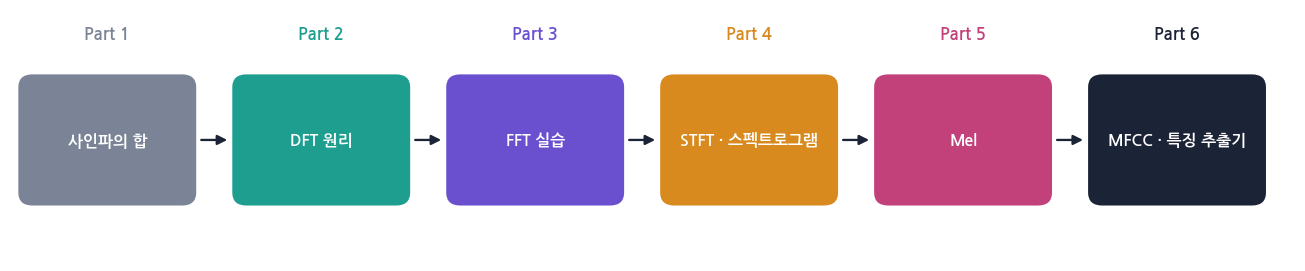

| 교시 | 내용 | 실습 |
|---|---|---|
| 1교시 | 사인파의 합, 배음과 포먼트, DFT 원리 | Part 1 ~ 2, 워크시트 1교시 |
| 2교시 | FFT 실습: 해상도, 창 함수, dB | Part 3, 워크시트 2교시 |
| 3교시 | STFT와 스펙트로그램, 트레이드오프 | Part 4, 워크시트 3교시 |
| 4교시 | Mel, Log-Mel, MFCC, 특징 추출기 | Part 5 ~ 7, 워크시트 4교시 · 노션 제출 |

## 오늘의 수업 자료
| 자료 | 링크 | 언제 쓰나요 |
|---|---|---|
| 🎬 인터랙티브 애니메이션 | [animation.html](https://imguru-mooc.github.io/AI_Voice/day03/animation.html) | 각 Part 설명을 볼 때 (Part마다 바로가기 링크가 있습니다) |
| 📝 개념 워크시트 | [worksheet.html](https://imguru-mooc.github.io/AI_Voice/day03/worksheet.html) | 각 교시 끝에 해당 탭 10문항 (4교시 × 10문항), 오답 캡처 → 노션 |

## 이 노트북 사용법
- ▶️ 일반 코드 셀은 위에서부터 차례로 실행합니다.
- 🧩 **빈칸 실습** 셀은 `____`(밑줄 4개)를 지우고 알맞은 값을 채운 뒤 실행합니다. 마지막 줄에서 ✅ 또는 ❌로 결과를 알려줍니다.
- 🔑 **정답 및 해설 보기**를 클릭하면 정답이 펼쳐집니다.
- 📐 **수식으로 보기**에서 원리를 수식으로 정리하고, ▶️ **수식 검증** 셀에서 예측값과 측정값을 비교합니다. 🔍 **코드 해설**은 주요 코드를 한 줄씩 설명합니다.

> ⚙️ 오늘은 GPU가 필요 없습니다. 기본 CPU 런타임으로 충분합니다.

> 🎬 **애니메이션 D3-1:** [오늘의 흐름](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#flow) — Part 1~6 로드맵

## Part 0. 준비
D2에서 만든 도우미 함수(`tone`, `make_model_ready`)를 다시 정의하고, 오늘 쓸 음성을 만듭니다.

In [ ]:
!pip install -q edge-tts librosa soundfile
print("✅ 설치 완료")

In [ ]:
import os, time, subprocess
import numpy as np
import scipy.fft as sfft
import librosa, librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

SR = 16000   # 음성 모델 표준 샘플링 레이트

def ffmpeg(*args):
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", *args], check=True)

def check(cond, hint="빈칸을 다시 확인하세요."):
    print("✅ 정답입니다! 🎉" if cond else f"❌ {hint}")

def tone(freq, sec=1.0, sr=SR, amp=0.5, phase=0.0):
    # x(t) = A·sin(2πft + φ)  (D2)
    t = np.arange(int(sr * sec)) / sr
    return (amp * np.sin(2 * np.pi * freq * t + phase)).astype(np.float32)

def make_model_ready(src, dst="ready.wav"):
    # 어떤 파일이든 16kHz mono 16bit WAV로 (D2 전처리기)
    y, sr = librosa.load(src, sr=16000, mono=True)
    y, _ = librosa.effects.trim(y, top_db=30)
    y = y / (np.abs(y).max() + 1e-9) * 0.9
    sf.write(dst, y, sr, subtype="PCM_16")
    return dst

print("🧩 준비 완료")

In [ ]:
import edge_tts

TEXT = "안녕하세요. 오늘은 소리를 주파수로 나누어 보는 방법을 배웁니다."
await edge_tts.Communicate(TEXT, "ko-KR-SunHiNeural").save("speech_f.mp3")    # 여성
await edge_tts.Communicate(TEXT, "ko-KR-InJoonNeural").save("speech_m.mp3")   # 남성
make_model_ready("speech_f.mp3", "speech.wav")
make_model_ready("speech_m.mp3", "speech_m.wav")

y, sr = librosa.load("speech.wav", sr=SR)
print(f"speech.wav: {sr} Hz, 샘플 {len(y):,}개, {len(y) / sr:.2f}초")
display(Audio(y, rate=sr))

## Part 1. 소리는 사인파의 합이다

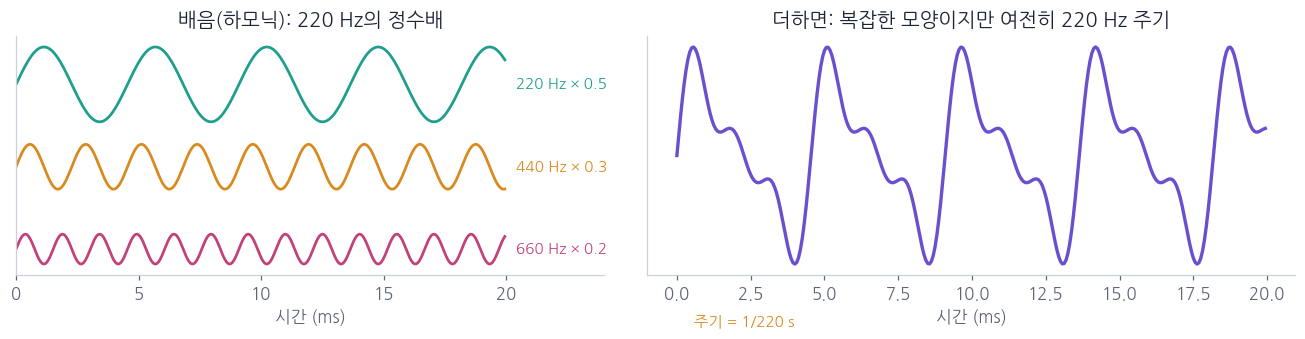

악기나 사람 목소리는 순수한 사인파 하나가 아닙니다. **기본 주파수 $f_0$**(음 높이)와 그 **정수배(배음, harmonics)**가 여러 크기로 섞인 소리입니다. 섞인 모양은 복잡해도, 반복 주기는 여전히 $1/f_0$입니다.

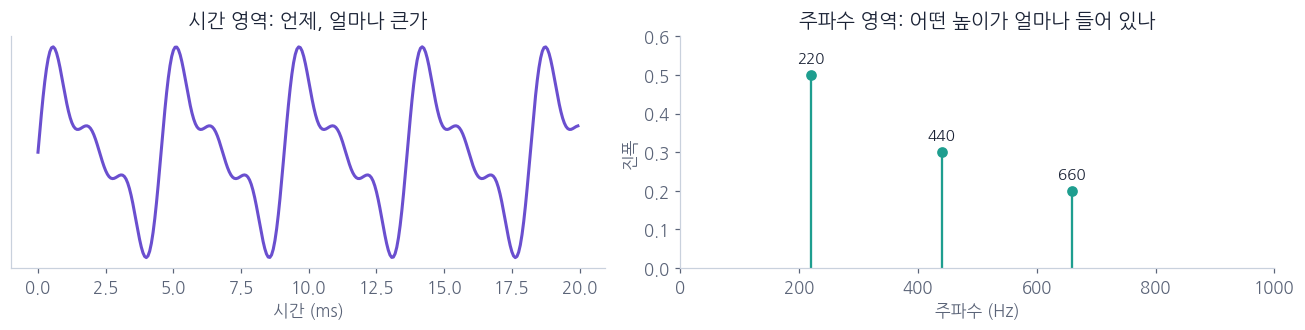

같은 소리를 두 가지 관점에서 볼 수 있습니다. **시간 영역**은 "언제 얼마나 큰가", **주파수 영역**은 "어떤 높이의 사인파가 얼마나 들어 있나"입니다. 오늘 배우는 FFT는 시간 영역을 주파수 영역으로 바꾸는 도구입니다.

> 🎬 **애니메이션 D3-2:** [사인파의 합](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#sum) — 배음 슬라이더로 파형을 직접 만들고 들어 보기

In [ ]:
parts = {"220 Hz × 0.5": tone(220, amp=0.5), "440 Hz × 0.3": tone(440, amp=0.3), "660 Hz × 0.2": tone(660, amp=0.2)}
mix = sum(parts.values())

for name, p in parts.items():
    print(name); display(Audio(p, rate=SR))
print("세 개를 더한 소리"); display(Audio(mix, rate=SR))

t_ms = np.arange(int(0.02 * SR)) / SR * 1000
plt.figure(figsize=(10, 2.6))
for name, p in parts.items():
    plt.plot(t_ms, p[:len(t_ms)], lw=1, label=name)
plt.plot(t_ms, mix[:len(t_ms)], "k", lw=2, label="sum")
plt.xlabel("time (ms)"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### 1-1. 📐 수식으로 보기: 푸리에 급수와 포먼트

**주기적인 소리는 사인파의 합으로 쓸 수 있습니다 (푸리에 급수).** 기본 주파수가 $f_0$이면

$$
x(t) = \sum_{k=1}^{K} A_k \sin(2\pi k f_0 t + \phi_k)
$$

- $k f_0$: $k$번째 배음 (220, 440, 660, … Hz)
- $A_k$: 각 배음의 크기 → **음색**을 결정
- 음 높이는 $f_0$이 정하고, 같은 높이라도 $A_k$가 다르면 다른 소리(피아노 vs 바이올린, "아" vs "이")

**모음과 포먼트**: 목소리는 성대가 만든 배음들($f_0$의 정수배)을 **성도(입, 혀, 목)**가 걸러서 만듭니다. 성도 모양에 따라 특정 높이 근처의 배음이 커지는데, 이 봉우리를 **포먼트**($F_1, F_2$)라 부릅니다.

$$
A_k \approx G(k f_0), \qquad G(f) = \text{성도의 필터 모양 (포먼트 봉우리)}
$$

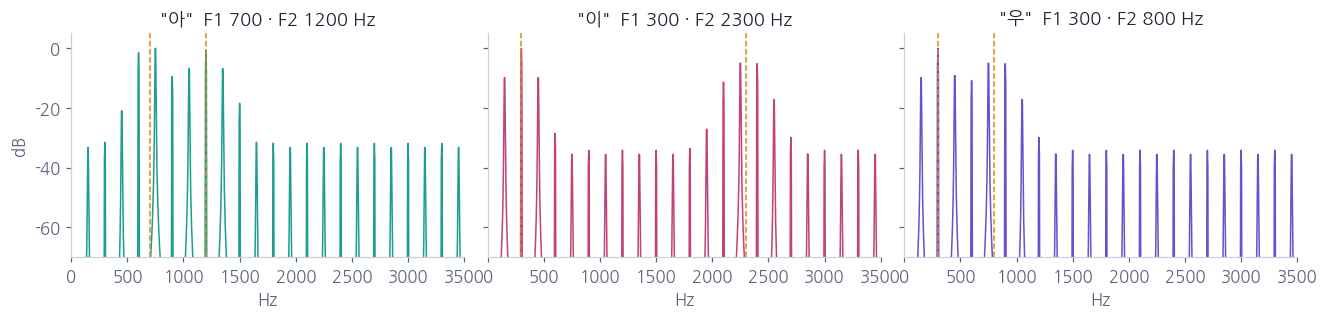

| 모음 | $F_1$ | $F_2$ | 입 모양 |
|---|---|---|---|
| 아 | 약 700 Hz | 약 1200 Hz | 입을 크게 |
| 이 | 약 300 Hz | 약 2300 Hz | 혀를 앞으로 |
| 우 | 약 300 Hz | 약 800 Hz | 입술을 둥글게 |

> 포먼트 값은 사람마다 다르며 표는 대표적인 예입니다. 오늘 Part 6의 MFCC는 바로 이 **봉우리 모양**을 숫자로 담는 특징입니다.

In [ ]:
def vowel(f0, F1, F2, sec=1.0, sr=SR):
    # 배음 f0, 2f0, 3f0, ...을 더하되, 포먼트 F1, F2 근처 배음을 크게 (간단한 포먼트 합성)
    t = np.arange(int(sr * sec)) / sr
    y = np.zeros_like(t)
    for k in range(1, int(sr / 2 / f0)):
        f = k * f0
        g = np.exp(-((f - F1) / 150) ** 2) + 0.7 * np.exp(-((f - F2) / 200) ** 2) + 0.02
        y += g * np.sin(2 * np.pi * f * t)
    return (0.8 * y / np.abs(y).max()).astype(np.float32)

VOWELS = {"아": (700, 1200), "이": (300, 2300), "우": (300, 800)}
for v, (F1, F2) in VOWELS.items():
    print(f'"{v}"  F1={F1} Hz, F2={F2} Hz'); display(Audio(vowel(150, F1, F2), rate=SR))

#### 🔍 코드 해설: vowel() 함수

| 코드 | 하는 일 |
|---|---|
| `range(1, int(sr / 2 / f0))` | 배음 번호 $k$. $k f_0$가 나이퀴스트 $f_s/2$를 넘지 않을 때까지만 (D2 샘플링 정리) |
| `f = k * f0` | $k$번째 배음의 주파수 |
| `np.exp(-((f - F1) / 150) ** 2)` | 가우스 모양 봉우리: $f$가 $F_1$에 가까울수록 1, 멀수록 0. 폭 150 Hz |
| `+ 0.7 * ... (F2) + 0.02` | 두 번째 포먼트(조금 작게)와 바닥값. 모든 배음이 아주 조금은 남게 |
| `y += g * np.sin(2*np.pi*f*t)` | $A_k \sin(2\pi k f_0 t)$를 하나씩 더함 → 푸리에 급수 그대로 |
| `0.8 * y / np.abs(y).max()` | peak normalize (D2). 최대 0.8 |

> 💡 같은 `vowel(150, ...)`에서 $f_0$만 220으로 바꾸면 음 높이는 바뀌지만 모음("아")은 그대로 들립니다. 포먼트($G(f)$)가 같기 때문입니다.

### 🧩 빈칸 실습 1: 도-미-솔 화음 만들기
`tone()`을 세 개 더해 "도(262) · 미(330) · 솔(392)" 화음을 만드세요. 아래 셀은 FFT로 세 높이가 모두 들어 있는지 검사합니다.

In [ ]:
# 🧩 빈칸 실습 1
chord = tone(262) + tone(330) + tone(____)        # 솔

display(Audio(chord, rate=SR))
spec = np.abs(np.fft.rfft(chord)); freqs = np.fft.rfftfreq(len(chord), 1 / SR)
peaks = sorted(int(round(p)) for p in freqs[np.argsort(spec)[-3:]])
print("가장 큰 세 주파수:", peaks)
check(peaks == [262, 330, 392], hint="솔은 392 Hz입니다.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
chord = tone(262) + tone(330) + tone(392)
```

**해설**: 세 사인파를 더하면 한 배열에 세 높이가 동시에 들어갑니다. 시간 파형으로는 구분하기 어렵지만, FFT로 보면 262, 330, 392 Hz에 정확히 봉우리가 생깁니다. 1초 신호라서 주파수 해상도가 $\Delta f = f_s/N = 1$ Hz이기 때문입니다 (Part 3).

</details>

## Part 2. DFT: 어떤 높이가 얼마나 들어 있는지 재는 방법

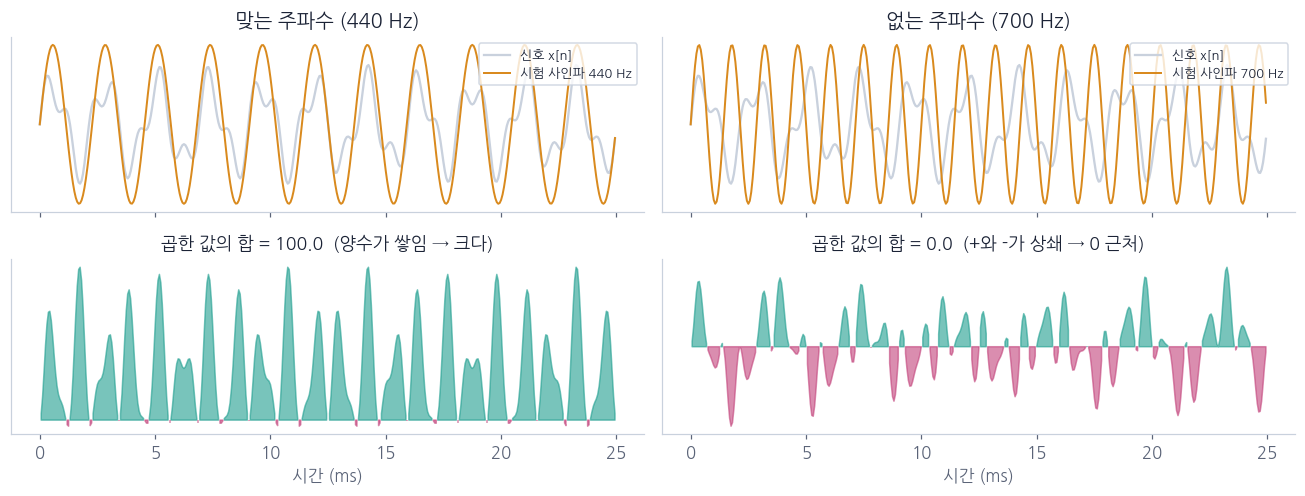

**아이디어**: 신호에 "440 Hz가 얼마나 들어 있나?"를 알고 싶으면, 440 Hz **시험 사인파를 곱해서 모두 더해** 봅니다.
- 신호에 440 Hz가 있으면 곱한 값이 대부분 양수 → 합이 **크다**
- 없으면 +와 −가 번갈아 나와 상쇄 → 합이 **0 근처**

이 "곱해서 더하기"를 모든 주파수에 대해 하는 것이 **DFT**(Discrete Fourier Transform)입니다.

> 🎬 **애니메이션 D3-3:** [DFT 원리](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#dft) — 시험 주파수를 움직이며 곱의 합이 커지는 순간을 찾고, 스펙트럼이 한 칸씩 채워지는 것 보기

In [ ]:
N = 400                                             # 25 ms
n = np.arange(N)
x = 0.5 * np.sin(2*np.pi*440*n/SR) + 0.25 * np.sin(2*np.pi*1000*n/SR)   # 440 Hz(0.5) + 1000 Hz(0.25)

print(f"{'시험 주파수':>10s} {'cos 곱의 합':>12s} {'sin 곱의 합':>12s} {'크기':>8s}")
for fp in [300, 440, 700, 1000, 1500]:
    c = np.sum(x * np.cos(2*np.pi*fp*n/SR))
    s = np.sum(x * np.sin(2*np.pi*fp*n/SR))
    print(f"{fp:8d} Hz {c:12.2f} {s:12.2f} {np.sqrt(c**2 + s**2) * 2 / N:8.3f}")
print("※ 300 Hz 등에서 0이 아닌 작은 값: 25 ms 안에 정수 주기가 딱 맞지 않아 생기는 '새어 나감'(Part 3)")

### 2-1. 📐 수식으로 보기: 오일러 공식과 DFT

**왜 cos와 sin을 둘 다 곱할까?** 신호의 위상 $\phi$를 모르기 때문입니다. sin만 곱하면 cos 모양으로 들어 있는 성분을 놓칩니다. 그래서 두 개를 함께 곱하고, 크기는 $\sqrt{c^2 + s^2}$로 합칩니다.

**오일러 공식**은 cos와 sin을 한 번에 다루게 해 줍니다. 반지름 1인 원 위를 도는 점(D2 사인파 유도)을 복소수로 쓴 것입니다.

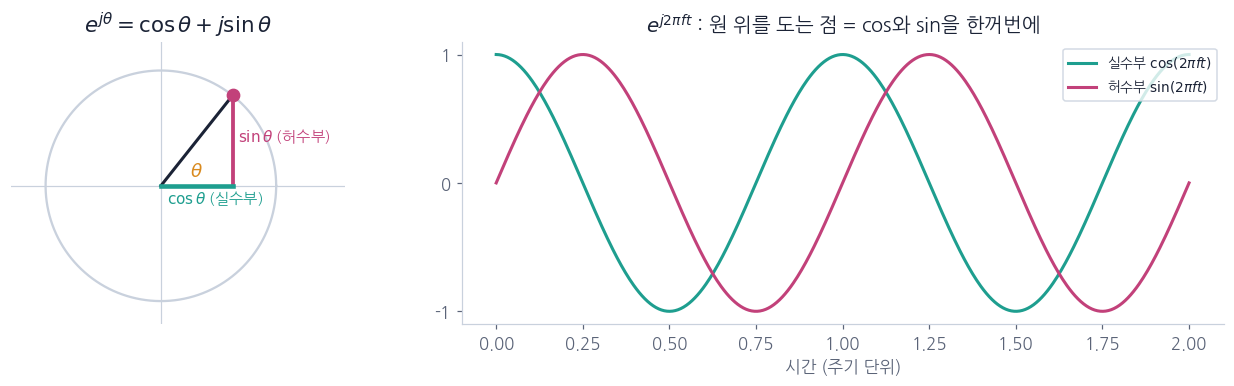

$$
e^{j\theta} = \cos\theta + j\sin\theta
\qquad\Rightarrow\qquad
e^{-j2\pi f t} = \cos(2\pi f t) - j\sin(2\pi f t)
$$

**DFT 정의**: 길이 $N$인 신호 $x[n]$에 대해, $k$번째 주파수 성분은

$$
X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-j 2\pi k n / N}
= \underbrace{\sum x[n]\cos\!\left(\tfrac{2\pi kn}{N}\right)}_{c_k} - j\underbrace{\sum x[n]\sin\!\left(\tfrac{2\pi kn}{N}\right)}_{s_k}
$$

| 기호 | 뜻 |
|---|---|
| $k$ | 주파수 번호(bin), $k = 0, 1, \dots, N-1$ |
| $f_k = k \cdot f_s / N$ | $k$번째 bin의 실제 주파수 (Hz) |
| $\lvert X[k] \rvert = \sqrt{c_k^2 + s_k^2}$ | 그 주파수의 세기 |
| $\angle X[k]$ | 위상 (오늘은 크기만 사용) |

**진폭 되돌리기**: 진폭 $A$인 사인파가 bin에 정확히 맞으면 $\lvert X[k]\rvert = A N / 2$ → $A = 2\lvert X[k]\rvert / N$. 위 표의 "크기" 열이 0.5, 0.25로 나온 이유입니다.

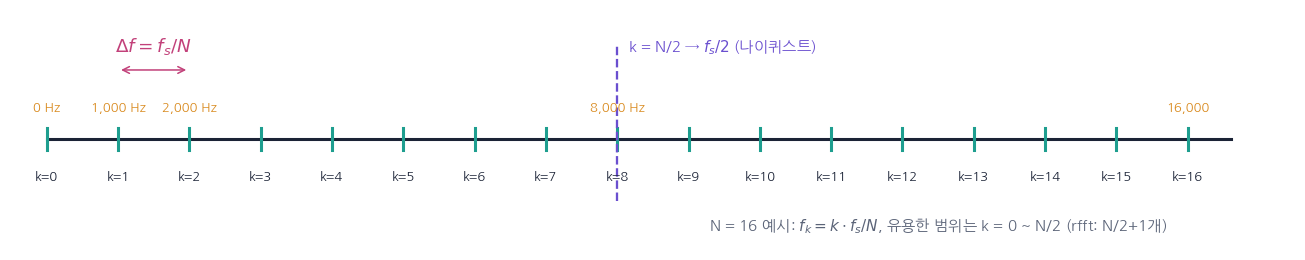

**FFT**(Fast Fourier Transform)는 DFT와 **결과가 똑같은** 빠른 계산법입니다. 곱셈 횟수가 $N^2$에서 $N\log_2 N$으로 줄어듭니다. $N = 1024$면 약 1,048,576 → 10,240번 (약 100배).

In [ ]:
def dft(x):
    # DFT 정의 그대로: X = W @ x,  W[k, n] = e^{-j2πkn/N}
    N = len(x)
    n = np.arange(N)
    k = n.reshape(-1, 1)
    W = np.exp(-2j * np.pi * k * n / N)      # N × N 행렬
    return W @ x

x = tone(440, sec=1024 / SR)                 # 1024 샘플 (64 ms)
t0 = time.perf_counter(); X1 = dft(x);       t_dft = time.perf_counter() - t0
t0 = time.perf_counter(); X2 = np.fft.fft(x); t_fft = time.perf_counter() - t0
print("결과가 같은가:", np.allclose(X1, X2, atol=1e-3))
print(f"직접 DFT {t_dft * 1000:.1f} ms | FFT {t_fft * 1000:.3f} ms | 약 {t_dft / t_fft:.0f}배 차이")

#### 🔍 코드 해설: dft() 함수

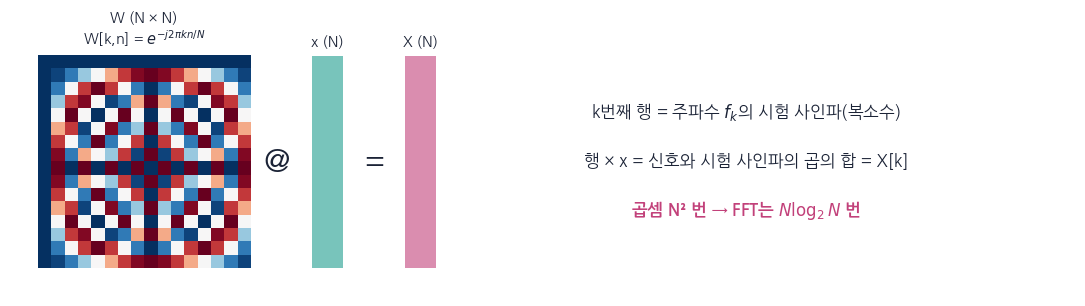

| 코드 | 하는 일 |
|---|---|
| `n = np.arange(N)` | 시간 번호 $n = 0 \dots N-1$ (가로) |
| `k = n.reshape(-1, 1)` | 주파수 번호 $k$를 세로 모양 $(N, 1)$로 → `k * n`이 브로드캐스팅으로 $(N, N)$ 표가 됨 |
| `W = np.exp(-2j * np.pi * k * n / N)` | $W[k, n] = e^{-j2\pi kn/N}$. 각 **행**이 $k$번째 시험 사인파(복소수). `2j`는 파이썬의 허수 $2j$ |
| `W @ x` | 행렬 × 벡터 = 각 행(시험 사인파)과 신호를 곱해서 더하기 → $X[k]$ |
| `np.allclose(X1, X2, atol=1e-3)` | float32 오차 정도만 다르면 같다고 판단 |

> ⚠️ 직접 DFT는 $N \times N$ 행렬을 만들어 메모리를 많이 씁니다. $N = 16000$(1초)이면 행렬만 약 4 GB라서 실습에서는 1024로 작게 합니다. 실전에서는 항상 `np.fft`를 씁니다.

### 🧩 빈칸 실습 2: bin 번호를 Hz로 바꾸기
FFT 결과의 $k$번째 칸은 $f_k = k \cdot f_s / N$ Hz입니다. 주파수 축을 만들고 가장 큰 봉우리가 440 Hz 근처인지 확인하세요.

In [ ]:
# 🧩 빈칸 실습 2
X = np.fft.fft(x)
N = len(x)
freqs = np.arange(N) * ____ / N            # f_k = k · f_s / N
mag = np.____(X)                           # 복소수 → 크기 |X[k]|

k_peak = np.argmax(mag[:N // 2])           # 앞쪽 절반(0 ~ f_s/2)에서 찾기
print(f"가장 큰 bin k = {k_peak} → {freqs[k_peak]:.1f} Hz  (bin 간격 Δf = {SR / N:.3f} Hz)")
check(abs(freqs[k_peak] - 440) < SR / N, hint="① 샘플링 레이트 변수 SR ② 절댓값 함수 abs")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
freqs = np.arange(N) * SR / N
mag = np.abs(X)
```

**해설**: $N = 1024$, $f_s = 16000$이면 bin 간격은 $15.625$ Hz입니다. 440 Hz는 $440/15.625 = 28.16$번째라서 가장 가까운 $k = 28$, 즉 **437.5 Hz**로 나옵니다. 정확히 440이 아닌 이유는 해상도 때문입니다 (Part 3). `np.abs()`는 복소수 $c - js$의 크기 $\sqrt{c^2+s^2}$를 계산합니다.

</details>

In [ ]:
# ▶️ 수식 검증 1: 진폭 되돌리기 A = 2|X[k]|/N  (bin에 정확히 맞는 주파수)
N = 1024
for f, A in [(500, 0.5), (1000, 0.25), (437.5, 0.8)]:      # 500 = 32·Δf, 1000 = 64·Δf, 437.5 = 28·Δf
    xx = tone(f, sec=N / SR, amp=A)
    k = round(f / (SR / N))
    print(f"{f:7.1f} Hz (k={k:3d}):  2|X[k]|/N = {2 * np.abs(np.fft.fft(xx))[k] / N:.4f}  | 실제 진폭 {A}")
print(f"\n곱셈 횟수  DFT N² = {N**2:,}  vs  FFT N·log2(N) = {int(N * np.log2(N)):,}  → 약 {N**2 / (N * np.log2(N)):.0f}배")

---
### 📝 1교시 마무리: 개념 워크시트

> **[worksheet.html 열기 → 1교시 탭](https://imguru-mooc.github.io/AI_Voice/day03/worksheet.html)** — 사인파의 합, 배음과 포먼트, DFT의 곱해서 더하기, 오일러 공식, bin 주파수, FFT 계산량
>
> 10문항을 풀고 **채점하기**를 누르세요. 결과 코드와 해설이 나옵니다. 채점 후에는 답이 잠깁니다. 제출은 4교시까지 모두 마친 뒤 한 번에 합니다.

## Part 3. FFT 실습: 해상도, 창 함수, dB

음성 분석에서는 실수 신호용 `np.fft.rfft()`를 씁니다. 결과의 앞쪽 절반($0 \sim f_s/2$)만 계산하므로 길이가 $N/2 + 1$입니다.

### 3-1. 📐 수식으로 보기: 주파수 해상도

$$
\Delta f = \frac{f_s}{N} = \frac{1}{T_{\text{window}}}, \qquad T_{\text{window}} = \frac{N}{f_s}
$$

**길게 볼수록 주파수를 촘촘히 구분합니다.** 25 ms(400샘플)로 자르면 $\Delta f = 40$ Hz, 1초면 1 Hz입니다. 440 Hz와 460 Hz처럼 가까운 두 소리를 구분하려면 $\Delta f$가 그 차이(20 Hz)보다 충분히 작아야 합니다.

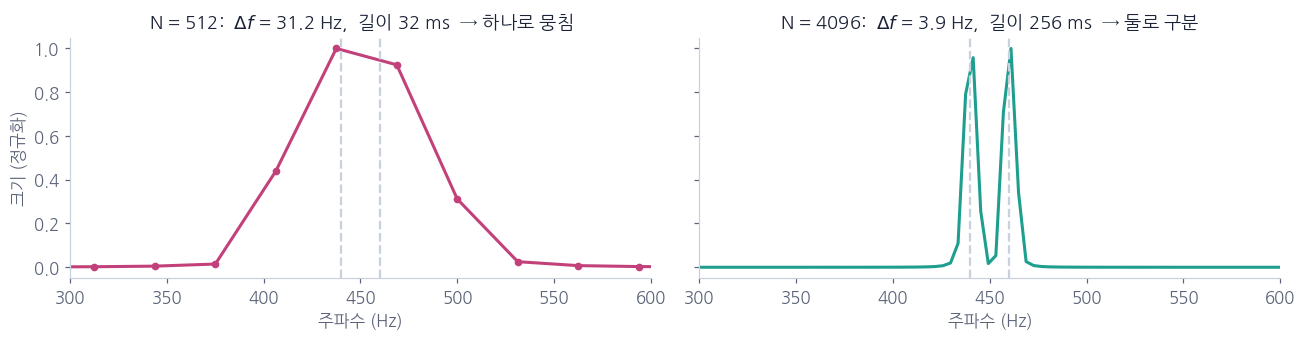

> 🎬 **애니메이션 D3-4:** [주파수 해상도](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#res) — N을 바꾸며 bin 간격과 두 소리의 구분 보기

In [ ]:
y2 = tone(440) + tone(460)                  # 20 Hz 차이 두 소리
fig, axs = plt.subplots(1, 2, figsize=(12, 3))
for ax, N in zip(axs, [512, 4096]):
    seg = y2[:N] * np.hanning(N)
    mag = np.abs(np.fft.rfft(seg)); f = np.fft.rfftfreq(N, 1 / SR)
    ax.plot(f, mag / mag.max(), "o-" if N == 512 else "-", ms=3)
    ax.set_xlim(300, 600); ax.set_title(f"N={N}, df={SR / N:.1f} Hz, {N / SR * 1000:.0f} ms"); ax.set_xlabel("Hz")
plt.tight_layout(); plt.show()
print("rfft 결과 길이:", len(np.fft.rfft(np.zeros(512))), "= 512/2 + 1")

### 3-2. 📐 수식으로 보기: 창 함수와 Spectral Leakage

신호를 $N$개로 **그냥 자르면**(직사각형 창) 끝부분이 갑자기 끊깁니다. 주파수가 bin에 딱 맞지 않으면(예: 445 Hz) 그 에너지가 주변 bin으로 넓게 **새어 나갑니다** (spectral leakage). 그래서 양 끝을 0으로 부드럽게 줄이는 **창 함수**를 곱한 뒤 FFT합니다.

**Hann 창**:

$$
w[n] = 0.5 - 0.5\cos\!\left(\frac{2\pi n}{N-1}\right), \qquad n = 0, \dots, N-1
$$

양 끝 $w[0] = w[N-1] = 0$, 가운데 $\approx 1$. 대가로 봉우리가 조금 넓어지지만, 멀리 새는 에너지가 크게 줄어듭니다.

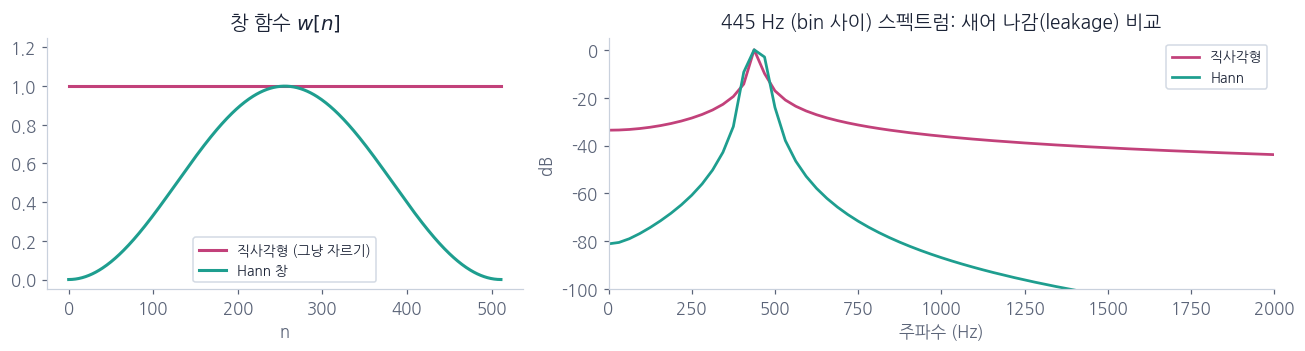

**데시벨로 보기**: 스펙트럼은 크기 차이가 매우 커서 dB로 봅니다 (D2). $\;L[k] = 20\log_{10}\dfrac{\lvert X[k]\rvert}{\max \lvert X \rvert}$ (최댓값 = 0 dB)

> 🎬 **애니메이션 D3-5:** [창 함수](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#window) — 직사각형과 Hann을 바꾸며 leakage 비교, 주파수를 bin 사이로 옮겨 보기

### 🧩 빈칸 실습 3: Hann 창 곱하기
numpy의 Hann 창 함수 이름을 채우세요. 아래 셀은 445 Hz(bin 사이)에서 직사각형과 Hann의 leakage를 비교합니다.

In [ ]:
# 🧩 빈칸 실습 3
N = 512
w = np.____(N)                              # Hann 창

x445 = tone(445, sec=N / SR)
f = np.fft.rfftfreq(N, 1 / SR)
for name, win in [("rect", np.ones(N)), ("hann", w)]:
    mag = np.abs(np.fft.rfft(x445 * win))
    db = 20 * np.log10(mag / mag.max() + 1e-12)
    print(f"{name}: 1,500 Hz 근처에 새어 나간 세기 = {db[np.argmin(np.abs(f - 1500))]:6.1f} dB")
    plt.plot(f, db, label=name)
plt.xlim(0, 2000); plt.ylim(-100, 5); plt.xlabel("Hz"); plt.ylabel("dB"); plt.legend(); plt.show()
check(abs(w[0]) < 1e-9 and abs(w.max() - 1) < 0.01, hint="numpy의 Hann 창은 np.hanning()입니다.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
w = np.hanning(N)
```

**해설**: `np.hanning(N)`은 위 Hann 식 그대로 만든 길이 $N$의 배열입니다(scipy의 `scipy.signal.get_window('hann', N)`도 비슷). 직사각형은 1,500 Hz에서도 약 −40 dB가 남지만 Hann은 −80 dB 아래로 떨어집니다. 그래서 STFT(Part 4)는 기본으로 Hann 창을 씁니다.

</details>

In [ ]:
# ▶️ 수식 검증 2: Δf = f_s/N, Hann 식, 실제 음성의 배음 간격
for N in [400, 1024, 16000]:
    f = np.fft.rfftfreq(N, 1 / SR)
    print(f"N={N:5d}: rfft 길이 {len(f):5d} = N/2+1, 칸 간격 {f[1]:.3f} Hz = f_s/N {SR / N:.3f}")

N = 8; n = np.arange(N)
print("\nHann 식  :", np.round(0.5 - 0.5 * np.cos(2 * np.pi * n / (N - 1)), 3))
print("np.hanning:", np.round(np.hanning(N), 3))

seg = vowel(150, 700, 1200, sec=0.256)        # f0 = 150 Hz 모음
mag = np.abs(np.fft.rfft(seg * np.hanning(len(seg)))); f = np.fft.rfftfreq(len(seg), 1 / SR)
pk = [f[i] for i in range(1, len(mag) - 1) if mag[i] > mag[i-1] and mag[i] > mag[i+1] and mag[i] > mag.max() * 0.05][:6]
print("\n'아' 배음 봉우리(Hz):", np.round(pk), "→ 간격 ≈ f0 = 150 Hz")

---
### 📝 2교시 마무리: 개념 워크시트

> **[worksheet.html 열기 → 2교시 탭](https://imguru-mooc.github.io/AI_Voice/day03/worksheet.html)** — rfft 길이, 주파수 해상도 Δf = f_s/N, 창 함수와 leakage, Hann 식, dB 스펙트럼
>
> 10문항을 풀고 **채점하기**를 누르세요. 결과 코드와 해설이 나옵니다. 채점 후에는 답이 잠깁니다. 제출은 4교시까지 모두 마친 뒤 한 번에 합니다.

## Part 4. STFT와 스펙트로그램

말소리는 시간에 따라 계속 바뀝니다. 전체를 한 번에 FFT하면 "언제" 정보가 사라지므로, **짧게 잘라(frame) 각각 FFT**합니다. 이것이 **STFT**(Short-Time Fourier Transform)이고, 결과를 이미지로 그린 것이 **스펙트로그램**입니다.

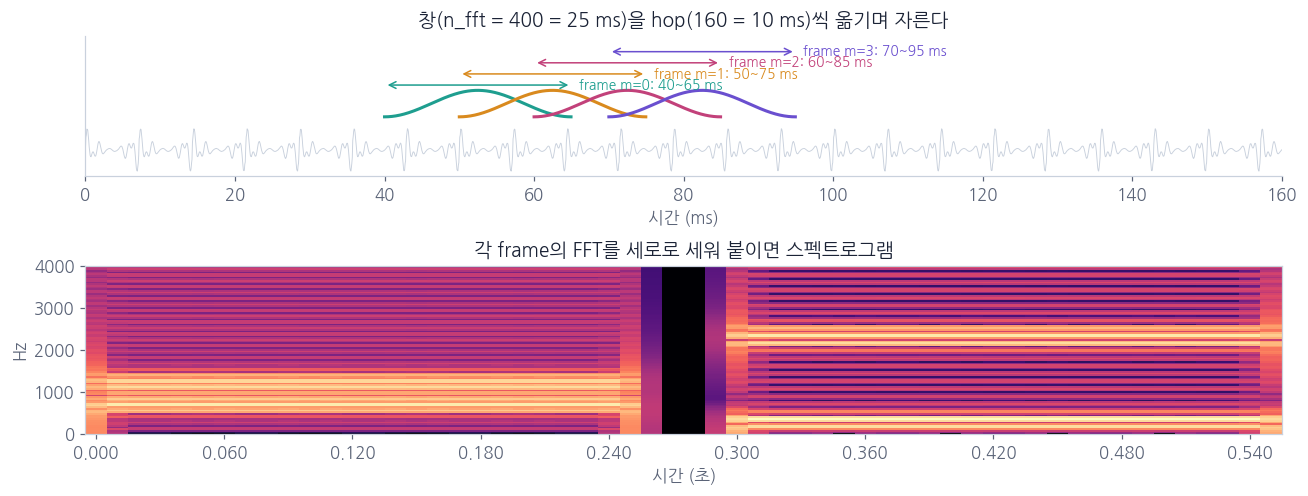

### 4-1. 📐 수식으로 보기: STFT

$$
X[m, k] = \sum_{n=0}^{N-1} x[n + mH]\; w[n]\; e^{-j 2\pi k n / N}
$$

| 기호 | 뜻 | Whisper 설정 |
|---|---|---|
| $N$ (`n_fft`) | 창 길이 | 400 샘플 = 25 ms |
| $H$ (`hop_length`) | 창을 옮기는 간격 | 160 샘플 = 10 ms |
| $w[n]$ | 창 함수 | Hann |
| $m$ | frame 번호 (시간) | |
| $k$ | bin 번호 (주파수), $0 \dots N/2$ | 201개 |

**결과 모양**: `(1 + N/2, frame 수)`. frame 수는

$$
\text{center=False}: \; M = 1 + \left\lfloor \frac{L - N}{H} \right\rfloor
\qquad
\text{center=True (librosa 기본)}: \; M = 1 + \left\lfloor \frac{L}{H} \right\rfloor
$$

`center=True`는 앞뒤에 $N/2$씩 덧대어(padding) 첫 frame의 가운데가 0초에 오게 합니다. 30초($L = 480{,}000$)면 $1 + 3000 = 3001$ → Whisper는 마지막 하나를 버려 **3000**을 씁니다.

> 🎬 **애니메이션 D3-6:** [STFT 프레이밍](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#stft) — 창이 미끄러지며 스펙트로그램 열이 하나씩 채워지는 과정, frame 수 계산

In [ ]:
def my_stft(y, n_fft=400, hop=160):
    # STFT 정의 그대로: 자르고 → 창 곱하고 → rfft  (center=False)
    w = np.hanning(n_fft + 1)[:-1]                  # librosa와 같은 '주기형' Hann
    M = 1 + (len(y) - n_fft) // hop                 # frame 수
    frames = np.stack([y[m * hop : m * hop + n_fft] * w for m in range(M)], axis=1)   # (n_fft, M)
    return np.fft.rfft(frames, axis=0)              # (1 + n_fft/2, M)

S1 = my_stft(y)
S2 = librosa.stft(y, n_fft=400, hop_length=160, window="hann", center=False)
print("my_stft:", S1.shape, "| librosa:", S2.shape, "| 같은가:", np.allclose(S1, S2, atol=1e-4))

#### 🔍 코드 해설: my_stft() 함수

| 코드 | 하는 일 |
|---|---|
| `np.hanning(n_fft + 1)[:-1]` | 길이 $N+1$로 만들고 끝 하나를 버린 '주기형' Hann. librosa(scipy)의 기본 창과 같아짐 |
| `M = 1 + (len(y) - n_fft) // hop` | frame 수 공식 $1 + \lfloor (L-N)/H \rfloor$ (center=False) |
| `y[m * hop : m * hop + n_fft] * w` | $m$번째 frame: 시작 $mH$에서 $N$개 자르고 창을 곱함 = $x[n+mH]\,w[n]$ |
| `np.stack([...], axis=1)` | frame을 **열**로 세워 $(N, M)$ 행렬. 시간이 가로가 되도록 |
| `np.fft.rfft(frames, axis=0)` | 각 열(세로 방향)을 한 번에 FFT → $(1 + N/2, M)$ 복소수 행렬 |

> 💡 결과 `S`는 복소수입니다. 세기는 `np.abs(S)`, 파워는 `np.abs(S)**2`, dB는 `librosa.amplitude_to_db(np.abs(S))`입니다.

In [ ]:
S_db = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=400, hop_length=160)), ref=np.max)
fig, ax = plt.subplots(figsize=(12, 3.5))
img = librosa.display.specshow(S_db, sr=SR, hop_length=160, x_axis="time", y_axis="hz", ax=ax)
fig.colorbar(img, ax=ax, format="%+2.0f dB"); ax.set_title("STFT spectrogram (n_fft=400, hop=160)")
plt.tight_layout(); plt.show()

### 4-2. 📐 수식으로 보기: 시간-주파수 트레이드오프

$$
\text{시간 해상도} \approx \frac{N}{f_s}, \qquad \text{주파수 해상도}\; \Delta f = \frac{f_s}{N}
\qquad\Rightarrow\qquad \frac{N}{f_s} \times \frac{f_s}{N} = 1
$$

**둘을 곱하면 항상 1**이라서, 한쪽을 좋게 하면 다른 쪽이 나빠집니다.

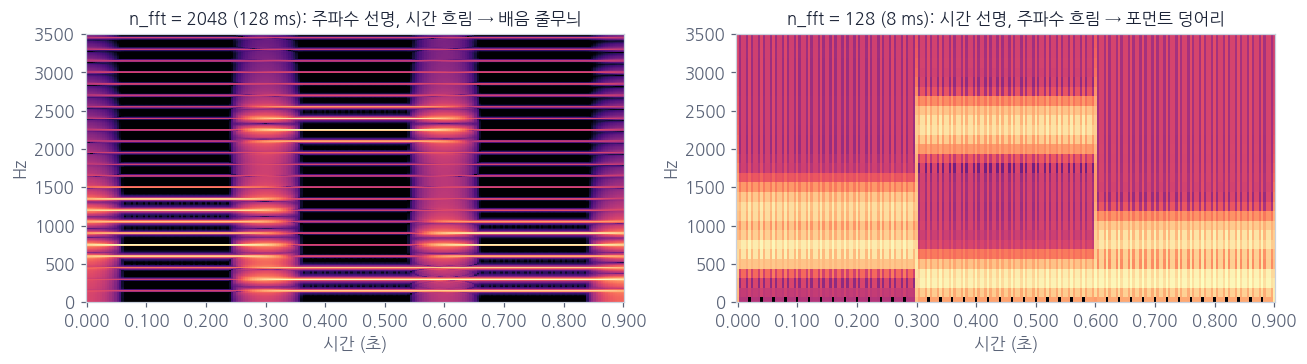

| `n_fft` | 창 길이 | $\Delta f$ | 보이는 것 | 이름 |
|---|---|---|---|---|
| 2048 | 128 ms | 7.8 Hz | 배음 하나하나가 가로 줄무늬 (음 높이) | 협대역(narrowband) |
| 400 | 25 ms | 40 Hz | 둘의 절충. 음성 인식 표준 | |
| 128 | 8 ms | 125 Hz | 배음이 뭉쳐 포먼트 덩어리 + 성대 진동이 세로 줄 | 광대역(wideband) |

> 🎬 **애니메이션 D3-7:** [시간-주파수 트레이드오프](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#live) — 마이크로 말하며 n_fft를 바꿔 실시간 스펙트로그램 비교

In [ ]:
ys = np.concatenate([vowel(150, *VOWELS[v], sec=0.3) for v in ["아", "이", "우"]])
fig, axs = plt.subplots(1, 3, figsize=(14, 3))
for ax, nf in zip(axs, [2048, 400, 128]):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(ys, n_fft=nf, hop_length=64)), ref=np.max)
    librosa.display.specshow(S, sr=SR, hop_length=64, x_axis="time", y_axis="hz", ax=ax)
    ax.set_ylim(0, 3500); ax.set_title(f"n_fft={nf} ({nf / SR * 1000:.0f} ms, df={SR / nf:.0f} Hz)")
plt.tight_layout(); plt.show()

### 🧩 빈칸 실습 4: Whisper 규격 STFT
Whisper와 같은 25 ms 창, **10 ms hop**으로 STFT를 만들고, frame 수가 공식과 같은지 확인하세요.

In [ ]:
# 🧩 빈칸 실습 4
n_fft = int(0.025 * SR)                     # 25 ms = 400
hop   = int(____ * SR)                      # 10 ms

S = librosa.stft(y, n_fft=n_fft, hop_length=hop)          # center=True (기본)
print(f"n_fft={n_fft}, hop={hop}, S.shape={S.shape}")
print(f"공식: (1 + n_fft/2, 1 + L//hop) = ({1 + n_fft // 2}, {1 + len(y) // hop})")
check(hop == 160 and S.shape == (201, 1 + len(y) // 160), hint="10 ms = 0.010초")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
hop = int(0.010 * SR)   # 160
```

**해설**: $0.010 \times 16000 = 160$샘플. 1초에 100 frame이 생깁니다. 세로 201은 $1 + 400/2$ bin이고, 각 bin 간격은 $16000/400 = 40$ Hz입니다. 25 ms 창이 10 ms씩 움직이므로 이웃 frame은 15 ms(60%) 겹칩니다.

</details>

In [ ]:
# ▶️ 수식 검증 3: frame 수 공식 (center False / True), 30초 = 3000 frame
L = len(y)
for center in [False, True]:
    S = librosa.stft(y, n_fft=400, hop_length=160, center=center)
    pred = 1 + (L - 400) // 160 if not center else 1 + L // 160
    print(f"center={center!s:5s}: 예측 {pred} | 실제 {S.shape[1]}")

L30 = 30 * SR
print(f"\n30초: 1 + {L30} // 160 = {1 + L30 // 160} → Whisper는 {L30 // 160} frame 사용")
print(f"겹침 비율 = (N - H) / N = (400 - 160) / 400 = {(400 - 160) / 400:.0%}")

---
### 📝 3교시 마무리: 개념 워크시트

> **[worksheet.html 열기 → 3교시 탭](https://imguru-mooc.github.io/AI_Voice/day03/worksheet.html)** — STFT 정의, n_fft와 hop, frame 수 공식, center 패딩, 결과 모양, 시간-주파수 트레이드오프
>
> 10문항을 풀고 **채점하기**를 누르세요. 결과 코드와 해설이 나옵니다. 채점 후에는 답이 잠깁니다. 제출은 4교시까지 모두 마친 뒤 한 번에 합니다.

## Part 5. Mel 스펙트로그램: 사람 귀에 맞춘 주파수 축

STFT의 201개 bin은 0 ~ 8,000 Hz를 **똑같은 간격(40 Hz)**으로 나눕니다. 그런데 사람은 낮은 소리의 차이(100 vs 200 Hz)는 잘 구분하지만 높은 소리의 차이(7,000 vs 7,100 Hz)는 거의 못 느낍니다. 그래서 낮은 쪽은 촘촘하게, 높은 쪽은 듬성듬성 묶습니다.

### 5-1. 📐 수식으로 보기: Mel 스케일과 필터뱅크

**Mel 변환** (HTK 공식, D2)과 역변환:

$$
m = 2595 \log_{10}\!\left(1 + \frac{f}{700}\right)
\qquad\Longleftrightarrow\qquad
f = 700\left(10^{\,m/2595} - 1\right)
$$

**필터뱅크 만드는 법**
1. $0 \sim f_s/2$를 mel로 바꾼 범위를 **같은 간격**으로 $M+2$개 점으로 나눈다 ($M$ = `n_mels`)
2. 그 점들을 다시 Hz로 바꾼다 → 낮은 쪽은 촘촘, 높은 쪽은 넓은 간격
3. 이웃한 세 점마다 **삼각형 필터** $H_m(k)$를 만든다

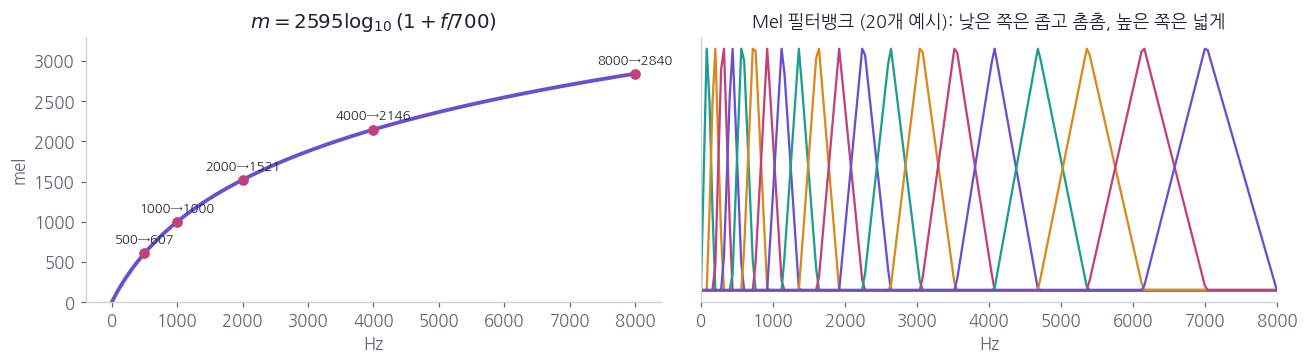

**Mel 스펙트로그램과 Log-Mel**: STFT 파워에 필터뱅크 행렬을 곱하고 로그를 취합니다.

$$
\text{Mel}[m, t] = \sum_{k} H_m(k)\, \lvert X[k, t] \rvert^2
\quad (\text{행렬로: } \mathbf{H}_{80 \times 201} \, \lvert \mathbf{X} \rvert^2_{201 \times T})
\qquad
\text{LogMel} = 10\log_{10}(\text{Mel})
$$

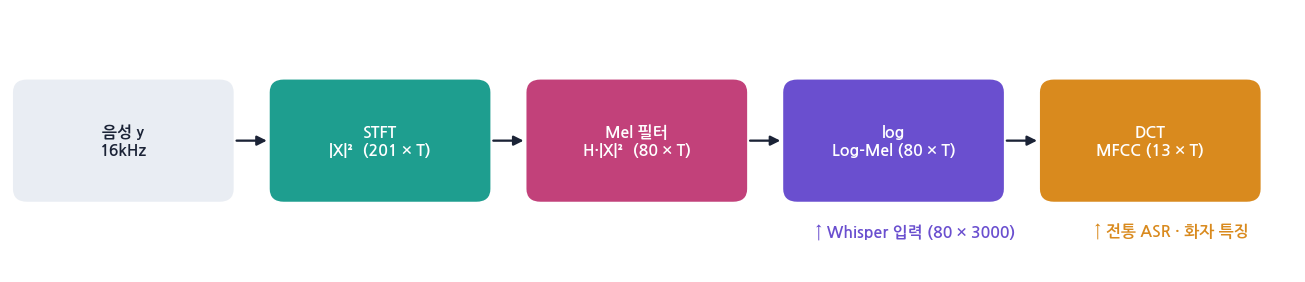

> 🎬 **애니메이션 D3-8:** [Mel 필터뱅크](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#mel) — n_mels를 바꿔 삼각형 필터의 배치 보기, Hz ↔ mel 계산기

In [ ]:
fb = librosa.filters.mel(sr=SR, n_fft=400, n_mels=80)        # (80, 201) 필터뱅크 행렬
print("필터뱅크 모양:", fb.shape, "= (n_mels, 1 + n_fft/2)")

P = np.abs(librosa.stft(y, n_fft=400, hop_length=160)) ** 2  # 파워 스펙트로그램 (201, T)
mel_manual = fb @ P                                           # (80, 201) @ (201, T) = (80, T)
mel_lib = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=400, hop_length=160, n_mels=80)
print("직접 곱한 Mel:", mel_manual.shape, "| librosa:", mel_lib.shape, "| 같은가:", np.allclose(mel_manual, mel_lib, rtol=1e-3, atol=1e-6))

fig, axs = plt.subplots(1, 2, figsize=(13, 3.2))
ff = np.fft.rfftfreq(400, 1 / SR)
for i in range(0, 80, 6): axs[0].plot(ff, fb[i])
axs[0].set_title("mel filters (every 6th of 80)"); axs[0].set_xlabel("Hz")
librosa.display.specshow(librosa.power_to_db(mel_lib, ref=np.max), sr=SR, hop_length=160, x_axis="time", y_axis="mel", ax=axs[1])
axs[1].set_title("log-mel spectrogram (80 mels)")
plt.tight_layout(); plt.show()

#### 🔍 코드 해설: Mel 스펙트로그램

| 코드 | 하는 일 |
|---|---|
| `librosa.filters.mel(sr, n_fft=400, n_mels=80)` | 삼각형 필터 80개를 행으로 쌓은 행렬 $\mathbf{H}$, 모양 $(80, 201)$. librosa 기본은 Slaney 방식(면적 정규화) |
| `np.abs(stft) ** 2` | 크기의 제곱 = **파워**. 에너지를 더하려면 파워로 계산 |
| `fb @ P` | 행렬 곱 = 각 필터가 담당 구간의 파워를 삼각형 가중치로 더함. 201개 bin → 80개 mel |
| `librosa.feature.melspectrogram(...)` | 위의 STFT → 파워 → 필터뱅크 곱을 한 번에 |
| `librosa.power_to_db(mel, ref=np.max)` | $10\log_{10}$ (파워라서 10). 최댓값 0 dB |

> 💡 `amplitude_to_db`는 크기(진폭)용으로 $20\log_{10}$, `power_to_db`는 파워용으로 $10\log_{10}$입니다. 둘은 같은 dB 값을 줍니다 ($10\log_{10}A^2 = 20\log_{10}A$).

### 🧩 빈칸 실습 5: Whisper 입력 만들기 (80 × 3000)
Whisper는 **80개 mel 채널**의 Log-Mel을 30초 단위로 받습니다. 음성을 30초로 패딩하고 Log-Mel을 만들어 모양을 확인하세요.

In [ ]:
# 🧩 빈칸 실습 5
y30 = np.pad(y, (0, 30 * SR - len(y)))                     # 30초까지 0으로 채우기
logmel = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y30, sr=SR, n_fft=400, hop_length=160, n_mels=____)
)[:, :3000]                                                 # 마지막 frame 버리기 (Whisper 방식)

print("Whisper 입력 모양:", logmel.shape)
check(logmel.shape == (80, 3000), hint="Whisper의 mel 채널 수는 80입니다 (D1 Part 5).")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
n_mels=80
```

**해설**: 30초 × 100 frame/초 = 3000 frame, mel 80채널 → $80 \times 3000$. 이것이 D1에서 그림으로만 봤던 "Whisper가 읽는 소리 그림"의 정확한 정체입니다. 실제 Whisper는 여기에 $\log_{10}$, 최댓값 −8 dB 아래 자르기, 스케일 조정을 더 합니다. (최신 large-v3는 128 mel을 씁니다.)

</details>

In [ ]:
# ▶️ 수식 검증 4: mel 공식, 역변환, 필터 중심의 간격
f = np.array([0, 500, 1000, 2000, 4000, 8000])
m = 2595 * np.log10(1 + f / 700)
f_back = 700 * (10 ** (m / 2595) - 1)
print("Hz      :", f)
print("mel     :", m.round(1), "| librosa(htk):", librosa.hz_to_mel(f, htk=True).round(1))
print("역변환 Hz:", f_back.round(1))

centers = librosa.mel_frequencies(n_mels=10 + 2, fmin=0, fmax=8000, htk=True)
print("\n필터 경계(Hz, 12개):", centers.round(0))
print("이웃 간격(Hz)       :", np.diff(centers).round(0), "→ 높을수록 넓어짐")

## Part 6. MFCC: 소리의 봉우리 모양을 13개 숫자로

Log-Mel은 80개 숫자인데 이웃끼리 비슷해서(상관) 중복이 많습니다. 또 그 안에는 **두 가지 정보**가 섞여 있습니다.

- **천천히 변하는 봉우리 모양** = 포먼트 = 성도 모양 = **무슨 소리(모음)인가**
- **빠르게 출렁이는 줄무늬** = 배음 = 성대 진동 = **음 높이**

MFCC(Mel-Frequency Cepstral Coefficients)는 Log-Mel에 **DCT**를 해서, 앞쪽 몇 개 계수에 **봉우리 모양**만 모읍니다.

### 6-1. 📐 수식으로 보기: DCT와 MFCC

$$
c_n = \sum_{m=0}^{M-1} \log(\text{Mel}_m)\, \cos\!\left[\frac{\pi n (m + 0.5)}{M}\right], \qquad n = 0, 1, \dots, 12
$$

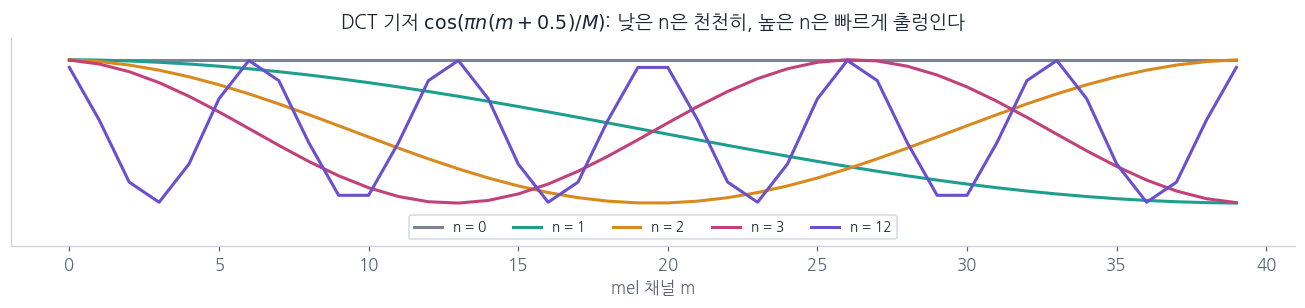

- DCT는 "Log-Mel 곡선을 **느린 cos부터 빠른 cos까지** 몇 개씩 섞으면 되는가"를 계산합니다 (DFT의 곱해서 더하기와 같은 원리, cos만 사용).
- **낮은 $n$** (천천히 출렁) → 전체적인 봉우리 모양. **높은 $n$** → 빠른 줄무늬(배음).
- 그래서 앞 **13개**만 남기면 포먼트는 남고 음 높이 정보는 대부분 빠집니다. $c_0$는 전체 크기(에너지)입니다.

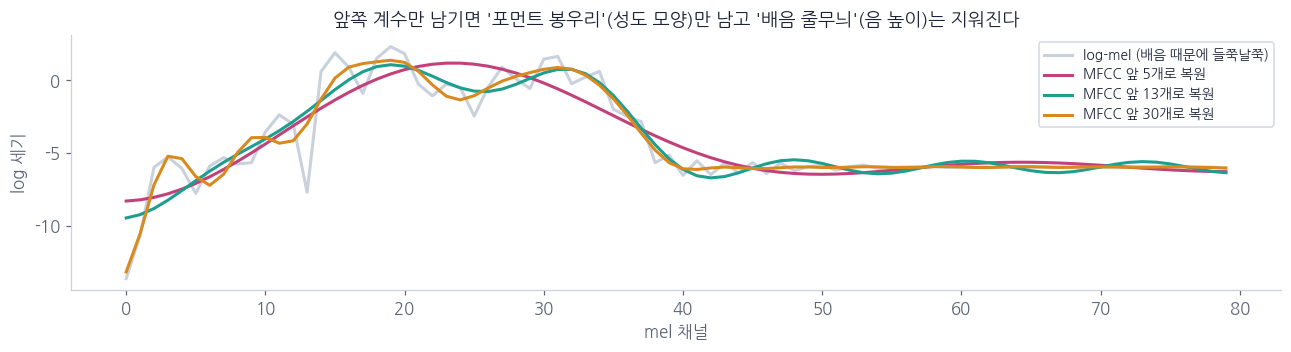

> 🎬 **애니메이션 D3-9:** [MFCC](https://imguru-mooc.github.io/AI_Voice/day03/animation.html#mfcc) — 계수 개수를 바꾸며 Log-Mel 곡선이 어떻게 복원되는지, 모음별 MFCC 비교

In [ ]:
logmel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=SR, n_fft=400, hop_length=160, n_mels=80))
mfcc = librosa.feature.mfcc(S=logmel, n_mfcc=13)
print("Log-Mel:", logmel.shape, "→ MFCC:", mfcc.shape)

c_manual = sfft.dct(logmel, type=2, axis=0, norm="ortho")[:13]
print("DCT로 직접 계산한 것과 같은가:", np.allclose(c_manual, mfcc, atol=1e-3))

fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
librosa.display.specshow(logmel, sr=SR, hop_length=160, x_axis="time", y_axis="mel", ax=axs[0]); axs[0].set_title("log-mel (80)")
librosa.display.specshow(mfcc, sr=SR, hop_length=160, x_axis="time", ax=axs[1]); axs[1].set_title("MFCC (13)"); axs[1].set_ylabel("coef")
plt.tight_layout(); plt.show()

#### 🔍 코드 해설: MFCC 계산

| 코드 | 하는 일 |
|---|---|
| `librosa.feature.mfcc(S=logmel, n_mfcc=13)` | 이미 만든 Log-Mel(dB)을 `S=`로 넘기면 DCT만 수행. `y=`로 넘기면 Mel부터 전부 계산 |
| `sfft.dct(logmel, type=2, axis=0, norm='ortho')` | DCT-II를 mel 축(세로, axis=0) 방향으로. `norm='ortho'`는 librosa와 같은 크기 조정 |
| `[:13]` | 앞 13개 계수만 → 봉우리 모양. 80 → 13으로 줄어듦 |
| `specshow(mfcc, ...)` | 가로 시간, 세로 계수 번호 $n = 0 \dots 12$ |

> 💡 librosa는 `power_to_db`(10·log10)를 쓰고, 교과서 식은 자연로그 $\log$를 씁니다. 로그 밑이 달라도 상수배 차이일 뿐 모양은 같습니다.

In [ ]:
# ▶️ 수식 검증 5: 앞 K개 계수만으로 Log-Mel 복원 → 봉우리만 남는다
yA = vowel(150, *VOWELS["아"], sec=0.2)
lm = librosa.power_to_db(librosa.feature.melspectrogram(y=yA, sr=SR, n_fft=400, hop_length=160, n_mels=80))[:, 5]
c = sfft.dct(lm, norm="ortho")
plt.figure(figsize=(11, 3))
plt.plot(lm, color="lightgray", lw=3, label="log-mel")
for K in [5, 13, 30]:
    cc = c.copy(); cc[K:] = 0
    plt.plot(sfft.idct(cc, norm="ortho"), label=f"first {K} MFCC")
plt.xlabel("mel channel"); plt.legend(); plt.tight_layout(); plt.show()
for K in [5, 13, 30, 80]:
    cc = c.copy(); cc[K:] = 0
    print(f"K={K:2d}: 복원 오차 {np.abs(sfft.idct(cc, norm='ortho') - lm).mean():.2f} dB")

### 🧩 빈칸 실습 6: 음 높이가 달라도 같은 모음이면 MFCC가 비슷할까?
같은 모음 "아"를 낮은 소리(120 Hz)와 높은 소리(240 Hz)로 만들고, 다른 모음 "이"와 MFCC 거리를 비교합니다. 전통적인 MFCC 개수를 채우세요.

In [ ]:
# 🧩 빈칸 실습 6
def mfcc_mean(sig):
    lm = librosa.power_to_db(librosa.feature.melspectrogram(y=sig, sr=SR, n_fft=400, hop_length=160, n_mels=80))
    return librosa.feature.mfcc(S=lm, n_mfcc=____)[1:].mean(axis=1)      # c0(전체 크기)는 빼고 평균

a_low, a_high, i_low = vowel(120, *VOWELS["아"]), vowel(240, *VOWELS["아"]), vowel(120, *VOWELS["이"])
d_same = np.linalg.norm(mfcc_mean(a_low) - mfcc_mean(a_high))
d_diff = np.linalg.norm(mfcc_mean(a_low) - mfcc_mean(i_low))
print(f'"아"120Hz vs "아"240Hz (같은 모음, 다른 높이): 거리 {d_same:6.1f}')
print(f'"아"120Hz vs "이"120Hz (다른 모음, 같은 높이): 거리 {d_diff:6.1f}')
check(len(mfcc_mean(a_low)) == 12 and d_same < d_diff, hint="전통적인 MFCC는 13개입니다.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
return librosa.feature.mfcc(S=lm, n_mfcc=13)[1:].mean(axis=1)
```

**해설**: 13개 중 $c_0$(전체 크기)를 빼면 12개입니다. 음 높이가 2배 달라도 같은 모음의 거리는, 높이가 같은 다른 모음과의 거리보다 작습니다. MFCC가 **음 높이보다 성도 모양(포먼트)**을 담기 때문입니다. 그래서 MFCC는 오랫동안 음성 인식과 화자 인식의 표준 특징이었습니다.

</details>

### 6-2. 미니 프로젝트: 음성 특징 추출기

오늘 배운 것을 묶어, 어떤 파일이든 **Whisper용 Log-Mel**과 **MFCC**를 한 번에 뽑는 함수를 만듭니다. D2의 `make_model_ready()` 다음 단계입니다.

| 단계 | 수식 / 코드 |
|---|---|
| 전처리 | `make_model_ready()` → 16kHz mono |
| STFT | $N = 400$, $H = 160$, Hann → $(201, T)$ |
| Mel | $\mathbf{H}_{80\times201}\lvert X\rvert^2$ → $(80, T)$ |
| Log | $10\log_{10}$ → Log-Mel |
| DCT | 앞 13개 → MFCC $(13, T)$ |

### 🧩 빈칸 실습 7: extract_features() 완성하기
STFT 설정 두 개(`n_fft`, `hop_length`)를 Whisper 규격으로 채우세요.

In [ ]:
# 🧩 빈칸 실습 7
def extract_features(src):
    path = make_model_ready(src, "feat_in.wav")
    y, sr = librosa.load(path, sr=16000)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=____, hop_length=____, n_mels=80)
    logmel = librosa.power_to_db(mel, ref=np.max)
    mfcc = librosa.feature.mfcc(S=logmel, n_mfcc=13)
    return {"logmel": logmel, "mfcc": mfcc, "sec": len(y) / sr}

feats = {name: extract_features(f) for name, f in [("여성", "speech.wav"), ("남성", "speech_m.wav")]}
for name, F in feats.items():
    print(f"{name}: {F['sec']:.2f}초 → Log-Mel {F['logmel'].shape}, MFCC {F['mfcc'].shape} (1초에 약 {F['mfcc'].shape[1] / F['sec']:.0f} frame)")

fig, axs = plt.subplots(2, 2, figsize=(13, 5))
for col, (name, F) in enumerate(feats.items()):
    librosa.display.specshow(F["logmel"], sr=16000, hop_length=160, x_axis="time", y_axis="mel", ax=axs[0, col]); axs[0, col].set_title(f"log-mel ({'F' if col == 0 else 'M'})")
    librosa.display.specshow(F["mfcc"], sr=16000, hop_length=160, x_axis="time", ax=axs[1, col]); axs[1, col].set_title(f"MFCC ({'F' if col == 0 else 'M'})")
plt.tight_layout(); plt.show()
F = feats["여성"]
check(F["logmel"].shape[0] == 80 and abs(F["mfcc"].shape[1] / F["sec"] - 100) < 3, hint="n_fft = 400, hop_length = 160")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=400, hop_length=160, n_mels=80)
```

**해설**: 25 ms 창(400), 10 ms hop(160)이면 1초에 100 frame이 나옵니다. 같은 문장을 여성과 남성 목소리로 비교하면, Log-Mel 아래쪽의 배음 간격(음 높이)은 다르지만 시간에 따른 큰 흐름(무슨 말인가)은 비슷합니다. D6부터 Whisper가 바로 이 Log-Mel을 입력으로 받습니다.

</details>

#### 🔍 코드 해설: extract_features()

| 코드 | 하는 일 |
|---|---|
| `make_model_ready(src, "feat_in.wav")` | D2 전처리기: 형식, 샘플링 레이트, 채널, 볼륨을 통일 |
| `melspectrogram(..., n_fft=400, hop_length=160, n_mels=80)` | STFT(Hann) → 파워 → 80개 mel 필터 곱을 한 번에. 결과 $(80, T)$ |
| `power_to_db(mel, ref=np.max)` | Log-Mel. 가장 큰 값이 0 dB, 나머지는 음수 |
| `mfcc(S=logmel, n_mfcc=13)` | DCT 앞 13개 → $(13, T)$ |
| `{"logmel": ..., "mfcc": ..., "sec": ...}` | 딕셔너리로 묶어 돌려줌. 다음 단계(모델 입력, 비교)에서 이름으로 꺼내 씀 |

---
### 📝 4교시 마무리: 개념 워크시트

> **[worksheet.html 열기 → 4교시 탭](https://imguru-mooc.github.io/AI_Voice/day03/worksheet.html)** — Mel 공식과 필터뱅크, Log-Mel, Whisper 80 × 3000, DCT, MFCC 13개, 포먼트 vs 음 높이
>
> 10문항을 풀고 **채점하기**를 누르세요. 결과 코드와 해설이 나옵니다. 채점 후에는 답이 잠깁니다. 제출은 4교시까지 모두 마친 뒤 한 번에 합니다. 4교시까지 마쳤다면 아래 Part 7의 **제출 방법**을 따라 노션에 제출하세요.

## Part 7. 정리 & 과제

### 오늘 배운 것
| 개념 | 핵심 | 수식 |
|---|---|---|
| 푸리에 급수 | 주기적인 소리 = 배음의 합 | $x(t) = \sum_k A_k \sin(2\pi k f_0 t + \phi_k)$ |
| 포먼트 | 성도가 만드는 봉우리, 모음을 결정 | $A_k \approx G(k f_0)$ |
| DFT | 시험 사인파와 곱해서 더하기 | $X[k] = \sum_n x[n] e^{-j2\pi kn/N}$ |
| bin 주파수 | $k$번째 칸의 Hz | $f_k = k f_s / N$, 진폭 $A = 2\lvert X[k]\rvert/N$ |
| FFT | DFT와 같은 결과, 빠른 계산 | $N^2 \to N\log_2 N$ |
| 해상도 | 길게 볼수록 촘촘 | $\Delta f = f_s / N$ |
| 창 함수 | leakage 줄이기 | $w[n] = 0.5 - 0.5\cos(2\pi n/(N-1))$ |
| STFT | 짧게 잘라 FFT | $X[m,k] = \sum_n x[n+mH] w[n] e^{-j2\pi kn/N}$, $M = 1 + \lfloor L/H \rfloor$ |
| 트레이드오프 | 시간과 주파수를 동시에 선명하게 볼 수 없다 | $(N/f_s)(f_s/N) = 1$ |
| Mel | 귀에 맞춘 주파수 축 | $m = 2595\log_{10}(1 + f/700)$, $\mathbf{H}\lvert X\rvert^2$ |
| MFCC | Log-Mel의 DCT 앞 13개 = 봉우리 모양 | $c_n = \sum_m \log \text{Mel}_m \cos[\pi n(m+0.5)/M]$ |

### 📝 과제
1. 마이크(또는 휴대폰 녹음)로 "아, 이, 우"를 녹음해 `extract_features()`로 MFCC 평균을 구하고, 모음끼리의 거리를 표로 비교하세요.
2. `n_fft`를 256, 400, 1024, 2048로 바꿔 같은 음성의 스펙트로그램을 그리고, 배음 줄무늬와 포먼트가 어떻게 달라지는지 두세 문장으로 정리하세요.
3. 빈칸 실습 2의 `dft()`로 $N = 256, 512, 1024, 2048$일 때 계산 시간을 재고 `np.fft.fft`와 비교해 그래프로 그리세요.

### ✅ 개념 워크시트 제출
4교시 탭까지 모두 채점했다면 오늘 내용을 정리해 제출합니다.

> 📝 **[D3 개념 워크시트 열기](https://imguru-mooc.github.io/AI_Voice/day03/worksheet.html)** — 4교시 × 10문항 (객관식 5 · OX 2 · 선잇기 1 · 순서 맞추기 1 · 모두 고르기 1)

**제출 방법 (노션)**
1. 4개 교시 탭을 모두 채점합니다.
2. **제출** 버튼을 눌러 오답 정리를 엽니다.
3. **📋 캡처 (노션용 복사)**를 누른 뒤, 노션 제출 페이지에서 `Ctrl + V`로 붙여 넣습니다. 이름, 교시별 점수, 오답 표(내 답과 정답)가 함께 붙습니다.

> 🎬 복습용: [애니메이션 전체 보기](https://imguru-mooc.github.io/AI_Voice/day03/animation.html)